In [1]:
print("hello world")
import pymcel as pc
import rebound as rb
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from IPython.display import HTML, display
import plotly.graph_objects as go
import spiceypy as spy
from scipy.optimize import curve_fit

hello world
Bienvenido a PyMCel v0.9.17 ¡al infinito y más allá!


In [2]:
T = 5033862 # canonical time unit in seconds
seconds_in_four_years = 4 * 365.25 * 24 * 3600

four_years_in_canon = (seconds_in_four_years / T)
print(f"Four years in canon time units is: {four_years_in_canon}")

Four years in canon time units is: 25.076253580253095


In [3]:
rb.horizons.SSL_CONTEXT = 'unverified'

In [4]:
sim = rb.Simulation()
date0 = '2010-01-01'

bodies = [
    ('Saturn', '699'),
    ('Janus', '610'),
    ('Epimetheus', '611'),
    ('Prometheus', '616'),
    ("Pandora", '617'),
    ("Mimas", '601')
]

for label, target in bodies:
    print(f"Adding {label} to the simulation.")
    sim.add(target, date=date0)

Adding Saturn to the simulation.
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Adding Janus to the simulation.
Searching NASA Horizons for '610'... 
Found: Janus (610) 
Adding Epimetheus to the simulation.
Searching NASA Horizons for '611'... 
Found: Epimetheus (611) 
Adding Prometheus to the simulation.
Searching NASA Horizons for '616'... 
Found: Prometheus (616) 
Adding Pandora to the simulation.
Searching NASA Horizons for '617'... 
Found: Pandora (617) 
Adding Mimas to the simulation.
Searching NASA Horizons for '601'... 
Found: Mimas (601) 


In [5]:
sim.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:44:35
Number of particles: 	6
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x1e44e65bd50, m=0.00028581500081698117 x=-9.46800446342915 y=0.26161067842824864 z=0.37221506693439704 vx=-0.02628140499999831 vy=-0.3248583414628617 vz=0.00667892483969261>
<rebound.particle.Particle object at 0x1e44e65ba50, m=9.537652224706244e-13 x=-9.467918441516842 y=0.2607178179389588 z=0.37267141591369773 vx=0.5053524442152856 vy=-0.3074699298167483 vz=-0.054206885978828744>
<rebound.particle.Particle object at 0x1e44e65bd50, m=2.646574267716062e-13 x=-9.467823933377128 y=0.26072258494212475 z=0.3726578709461376 vx=0.49634974037559293 vy=-0.2576805380203303 vz=-0.08167533827266592>
<rebound.particle.Particle object at 0x1e44e65ba50, m=8.101787599322461e-14 x=-9.467341680780482 y=

In [6]:
N = len(sim.particles)

In [7]:
ts = np.linspace(0, four_years_in_canon*4,2000)
rps = np.zeros((N, 2000, 3))
vps = np.zeros((N, 2000, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    sim.move_to_com()
    for j in range(N):
        rps[j, i] = sim.particles[j].xyz
        vps[j, i] = sim.particles[j].vxyz

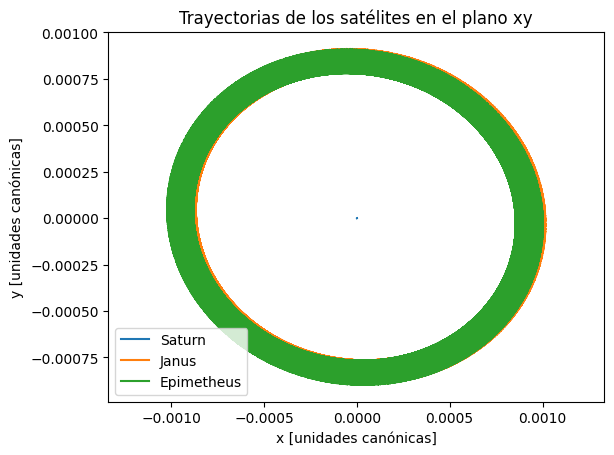

In [9]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Saturn')
plt.plot(rps[1,:,0], rps[1,:,1], label='Janus')
plt.plot(rps[2,:,0], rps[2,:,1], label='Epimetheus')
plt.xlabel('x [unidades canónicas]')
plt.ylabel('y [unidades canónicas]')
plt.title('Trayectorias de los satélites en el plano xy')
plt.legend()
plt.axis('equal')
plt.show()

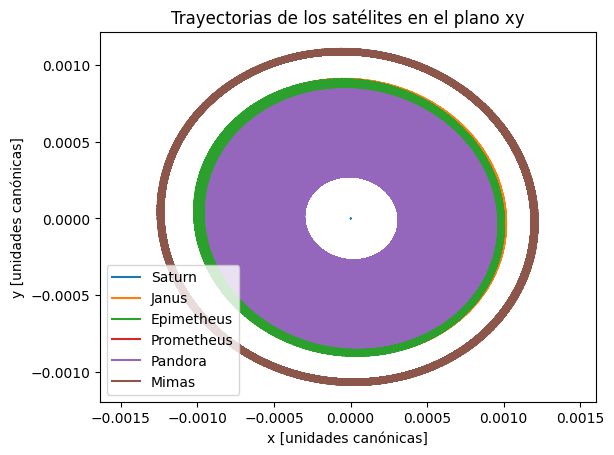

In [10]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Saturn')
plt.plot(rps[1,:,0], rps[1,:,1], label='Janus')
plt.plot(rps[2,:,0], rps[2,:,1], label='Epimetheus')
plt.plot(rps[3,:,0], rps[3,:,1], label='Prometheus')
plt.plot(rps[4,:,0], rps[4,:,1], label='Pandora')
plt.plot(rps[5,:,0], rps[5,:,1], label='Mimas')
plt.xlabel('x [unidades canónicas]')
plt.ylabel('y [unidades canónicas]')
plt.title('Trayectorias de los satélites en el plano xy')
plt.legend()
plt.axis('equal')
plt.show()


In [11]:
def animar_sistema_2d(rs, ts):
 fig, ax = plt.subplots(figsize=(6, 6))
 camera = Camera(fig)

 # Limit the animation to Apophis through Jupiter.
 n_particles = min(8, rs.shape[0])
 rs = rs[:n_particles]

 # Fondo del grafico (una sola vez).
 ax.set_aspect('equal', adjustable='box')
 ax.grid(alpha=0.3)

 # Menos cuadros => render mas rapido.
 step = 10
 colors = plt.cm.viridis(np.linspace(0, 1, n_particles))

 for i in range(0, len(ts), step):
    for p in range(n_particles):
        # Resaltar el cuerpo central (indice 0).
        lw = 1.2 if p == 0 else 0.8
        alpha = 0.35 if p == 0 else 0.2
        ms = 7 if p == 0 else 3

        ax.plot(rs[p, :, 0], rs[p, :, 1], '-', color=colors[p], lw=lw, alpha=alpha)
        ax.plot(rs[p, i, 0], rs[p, i, 1], 'o', color=colors[p], ms=ms)

    camera.snap()

 anim = camera.animate(interval=60, blit=False)
 #anim.save("my_animation.gif", writer="pillow", fps=20)
 plt.close(fig)

 return HTML(anim.to_jshtml())

In [12]:
#animar_sistema_2d(rps, ts)

In [13]:
def anima_ncuerpos(masas, rps, T):
    N = rps.shape[0]
    Nt = rps.shape[1]
    T_total = Nt * (T / Nt)  # tiempo total de la simulación
    
    # Colores de las partículas
    colors_hex = [f'hsl({int(j/N*360)},70%,50%)' for j in range(N)]

    # Submuestreo para que la animación sea fluida pero no pesada
    n_frames = 120
    idx = np.linspace(0, Nt - 1, n_frames, dtype=int)
    s_markers = [min(30, max(4, int(masas[j] * 120 + 4))) for j in range(N)]

    base_traces = []
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=rps[j, :, 0], y=rps[j, :, 1], z=rps[j, :, 2],
            mode='lines',
            line=dict(color=colors_hex[j], width=1),
            opacity=0.25,
            showlegend=False,
            hoverinfo='skip'
        ))

    # Posiciones iniciales de los cuerpos (frame 0)
    for j in range(N):
        base_traces.append(go.Scatter3d(
            x=[rps[j, idx[0], 0]],
            y=[rps[j, idx[0], 1]],
            z=[rps[j, idx[0], 2]],
            mode='markers',
            marker=dict(color=colors_hex[j], size=s_markers[j],
                        line=dict(color='black', width=0.5)),
            name=f'Cuerpo {j+1}',
            showlegend=False
        ))

    frames = []
    for fi, ki in enumerate(idx):
        frame_data = []
        # Las N primeras trazas son trayectorias (no cambian); actualizamos sólo las N de puntos
        for j in range(N):
            frame_data.append(go.Scatter3d(
                x=[rps[j, ki, 0]],
                y=[rps[j, ki, 1]],
                z=[rps[j, ki, 2]],
            ))
        frames.append(go.Frame(
            data=frame_data,
            traces=list(range(N, 2 * N)),   # índices de las trazas de puntos
            name=str(fi)
        ))

    fig_anim = go.Figure(data=base_traces, frames=frames)
    fig_anim.update_layout(
        title=dict(
            text=f'Animación 3D — {N} cuerpos — T = {T_total} u.t.c.',
            x=0.5
        ),
        scene=dict(
            xaxis_title='x [u.c.]',
            yaxis_title='y [u.c.]',
            zaxis_title='z [u.c.]',
            aspectmode='data'
        ),
        width=860, height=760,
        margin=dict(l=0, r=0, b=0, t=50),
        updatemenus=[dict(
            type='buttons',
            showactive=False,
            y=0.02, x=0.5, xanchor='center',
            buttons=[
                dict(label='▶ Play',
                    method='animate',
                    args=[None, dict(frame=dict(duration=40, redraw=True),
                                    fromcurrent=True, mode='immediate')]),
                dict(label='⏸ Pausa',
                    method='animate',
                    args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')])
            ]
        )],
        sliders=[dict(
            currentvalue=dict(prefix='Frame: ', visible=True, xanchor='center'),
            pad=dict(t=40),
            steps=[dict(method='animate',
                        args=[[str(fi)], dict(mode='immediate',
                                            frame=dict(duration=0, redraw=True))],
                        label=str(fi))
                for fi in range(n_frames)]
        )]
    )
    fig_anim.show()

In [14]:
# masas = [sim.particles[i].m for i in range(N)]
# anima_ncuerpos(masas, rps, T=four_years_in_canon)

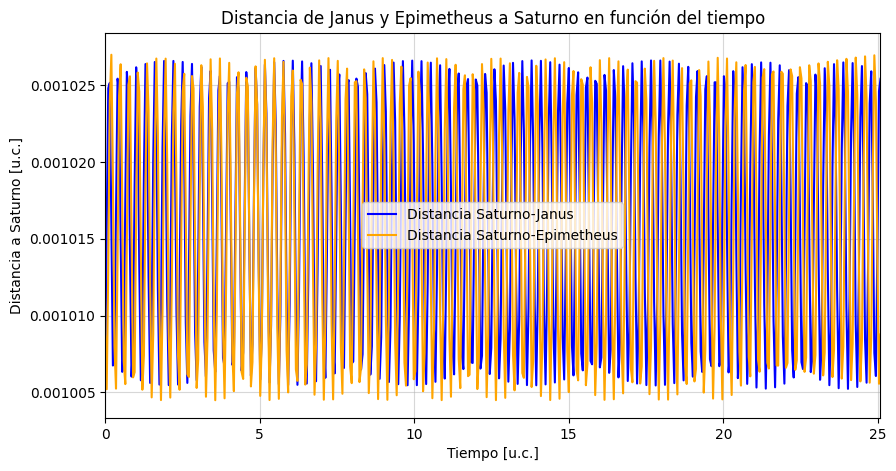

In [15]:
# Calculamos las distancias de las lunas a Saturno en cada instante de tiempo
d_janus = np.linalg.norm(rps[1, :, :] - rps[0, :, :], axis=1)
d_epimetheus = np.linalg.norm(rps[2, :, :] - rps[0, :, :], axis=1)

# Graficamos
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts, d_janus, label='Distancia Saturno-Janus', color='blue')
ax.plot(ts, d_epimetheus, label='Distancia Saturno-Epimetheus', color='orange')

# Limit plotting range to the first 4 years in canonical units
ax.set_xlim(0, four_years_in_canon)

ax.set_xlabel('Tiempo [u.c.]')
ax.set_ylabel('Distancia a Saturno [u.c.]')
ax.set_title('Distancia de Janus y Epimetheus a Saturno en función del tiempo')
ax.legend()
ax.grid(alpha=0.5)

plt.show()

In [8]:
# Medio año en unidades de tiempo canónicas
half_year_canon = four_years_in_canon / 8

# Lista para guardar los estados de las lunas cada medio año
yearly_states = []

for step in range(len(ts)): # 0 a 16 años (en pasos de medio año, 33 puntos)
    #target_t = step * half_year_canon
    # Encontramos el índice en 'ts' más cercano a 'target_t'
    #idx = np.argmin(np.abs(ts - target_t))

    idx = step  # Dado que 'ts' ya tiene 1000 puntos distribuidos uniformemente, podemos usar 'step' directamente como índice
    
    state = {
        'year': step * 0.5,
        'time_canon': ts[idx],
        'saturn_pos': rps[0, idx, :],
        'saturn_vel': vps[0, idx, :],
        'janus_pos': rps[1, idx, :],
        'janus_vel': vps[1, idx, :],
        'epimetheus_pos': rps[2, idx, :],
        'epimetheus_vel': vps[2, idx, :]
    }
    yearly_states.append(state)

# Imprimimos los resultados para los primeros 3 (ahora representan 0, 0.5 y 1.0 años) a modo de prueba
for s in yearly_states[:3]:
    print(f"--- Año {s['year']} ---")
    print(f"Saturn Pos: {s['saturn_pos']}")
    print(f"Janus Pos: {s['janus_pos']}")
    print(f"Epimetheus Pos: {s['epimetheus_pos']}\n")

--- Año 0.0 ---
Saturn Pos: [ 7.59232677e-11 -2.74599787e-11  9.61264401e-12]
Janus Pos: [ 8.60219882e-05 -8.92860517e-04  4.56348989e-04]
Epimetheus Pos: [ 0.00018053 -0.00088809  0.0004428 ]

--- Año 0.5 ---
Saturn Pos: [ 7.88564502e-11  4.92013716e-12 -7.80499014e-12]
Janus Pos: [ 0.00092903 -0.00039348  0.00011422]
Epimetheus Pos: [ 9.52340389e-04 -3.14830173e-04  6.61018240e-05]

--- Año 1.0 ---
Saturn Pos: [ 6.64331640e-11  3.49595609e-11 -2.30849028e-11]
Janus Pos: [ 0.00081298  0.00051745 -0.0003486 ]
Epimetheus Pos: [ 0.00073213  0.00058792 -0.00038026]



In [17]:
spy.oscelt?

Signature: spy.oscelt(state: numpy.ndarray, et: float, mu: Union[float, int]) -> numpy.ndarray
Docstring:
Determine the set of osculating conic orbital elements that
corresponds to the state (position, velocity) of a body at
some epoch.

https://naif.jpl.nasa.gov/pub/naif/misc/toolkit_docs_N0067/C/cspice/oscelt_c.html

:param state: State of body at epoch of elements.
:param et: Epoch of elements in ephemeris seconds past J2000.
:param mu: Gravitational parameter (GM) of primary body in km**3/sec**2 units.
:return: Equivalent conic elements in  km, rad, rad/sec units.
File:      c:\users\jaide\onedrive\documentos\visual_projects\meccel-20261\meccelenv312\lib\site-packages\spiceypy\spiceypy.py
Type:      function

In [9]:
#Listas para almacenar los elementos orbitales a lo largo del tiempo para Janus

q_s_j = [] #periapsis
Q_s_j = [] #apoapsis
e_s_j = [] #excentricidad
i_s_j = [] #inclinación
Omega_s_j = [] #longitud del nodo ascendente
omega_s_j = [] #argumento del periastro
M_s_j = [] #anomalía media
tp_s_j = [] #tiempo de paso por el periastro
mu_s_j = [] #parámetro gravitacional
a_s_j = [] #semieje mayor

#Lista para almacenar los elementos orbitales a lo largo del tiempo para Epimetheus

q_s_e = [] #periapsis
Q_s_e = [] #apoapsis
e_s_e = [] #excentricidad
i_s_e = [] #inclinación
Omega_s_e = [] #longitud del nodo ascendente
omega_s_e = [] #argumento del periastro
M_s_e = [] #anomalía media
tp_s_e = [] #tiempo de paso por el periastro
mu_s_e = [] #parámetro gravitacional
a_s_e = [] #semieje mayor

# Definimos factores de conversión
AU_in_km = 149597870.7  # 1 AU en kilómetros
V_canon_to_kms = AU_in_km / T  # Conversión de velocidad de c.u. a km/s

mu_saturn_km = pc.constantes.mu_saturn * 1e-9

for i in range(len(yearly_states)):
    # spiceypy DEBE recibir el vector de estado RELATIVO al cuerpo central (Saturno).
    # Como los datos fueron integrados y salvados alrededor del baricentro del sistema, 
    # restamos la posición y velocidad de Saturno.
    pos_j_rel = (yearly_states[i]['janus_pos'] - yearly_states[i]['saturn_pos']) * AU_in_km
    vel_j_rel = (yearly_states[i]['janus_vel'] - yearly_states[i]['saturn_vel']) * V_canon_to_kms

    state_vector = np.concatenate((pos_j_rel, vel_j_rel))
    et_time = yearly_states[i]['time_canon'] * T  # Mantenemos el tiempo en segundos
    
    oscelt_result = spy.oscelt(state=state_vector, et=et_time, mu=mu_saturn_km)
    
    q_s_j.append(oscelt_result[0])
    e_s_j.append(oscelt_result[1])
    i_s_j.append(oscelt_result[2])
    Omega_s_j.append(oscelt_result[3])
    omega_s_j.append(oscelt_result[4])
    M_s_j.append(oscelt_result[5])
    tp_s_j.append(oscelt_result[6])
    mu_s_j.append(oscelt_result[7])

    a_j = oscelt_result[0] / (1 - oscelt_result[1])  # Semieje mayor = q / (1 - e)
    a_s_j.append(a_j) 
    Q_s_j.append(a_j * (1 + oscelt_result[1]))  # Apoapsis

    # Conversión para Epimetheus (también restando a Saturno para obtener estado relativo)
    pos_e_rel = (yearly_states[i]['epimetheus_pos'] - yearly_states[i]['saturn_pos']) * AU_in_km
    vel_e_rel = (yearly_states[i]['epimetheus_vel'] - yearly_states[i]['saturn_vel']) * V_canon_to_kms
    state_vector_e = np.concatenate((pos_e_rel, vel_e_rel))
    
    oscelt_result_e = spy.oscelt(state=state_vector_e, et=et_time, mu=mu_saturn_km)
    
    q_s_e.append(oscelt_result_e[0])
    e_s_e.append(oscelt_result_e[1])
    i_s_e.append(oscelt_result_e[2])
    Omega_s_e.append(oscelt_result_e[3])
    omega_s_e.append(oscelt_result_e[4])
    M_s_e.append(oscelt_result_e[5])
    tp_s_e.append(oscelt_result_e[6])
    mu_s_e.append(oscelt_result_e[7])

    a_e = oscelt_result_e[0] / (1 - oscelt_result_e[1])  # Semieje mayor = q / (1 - e)
    a_s_e.append(a_e)
    Q_s_e.append(a_e * (1 + oscelt_result_e[1]))  # Apoapsis


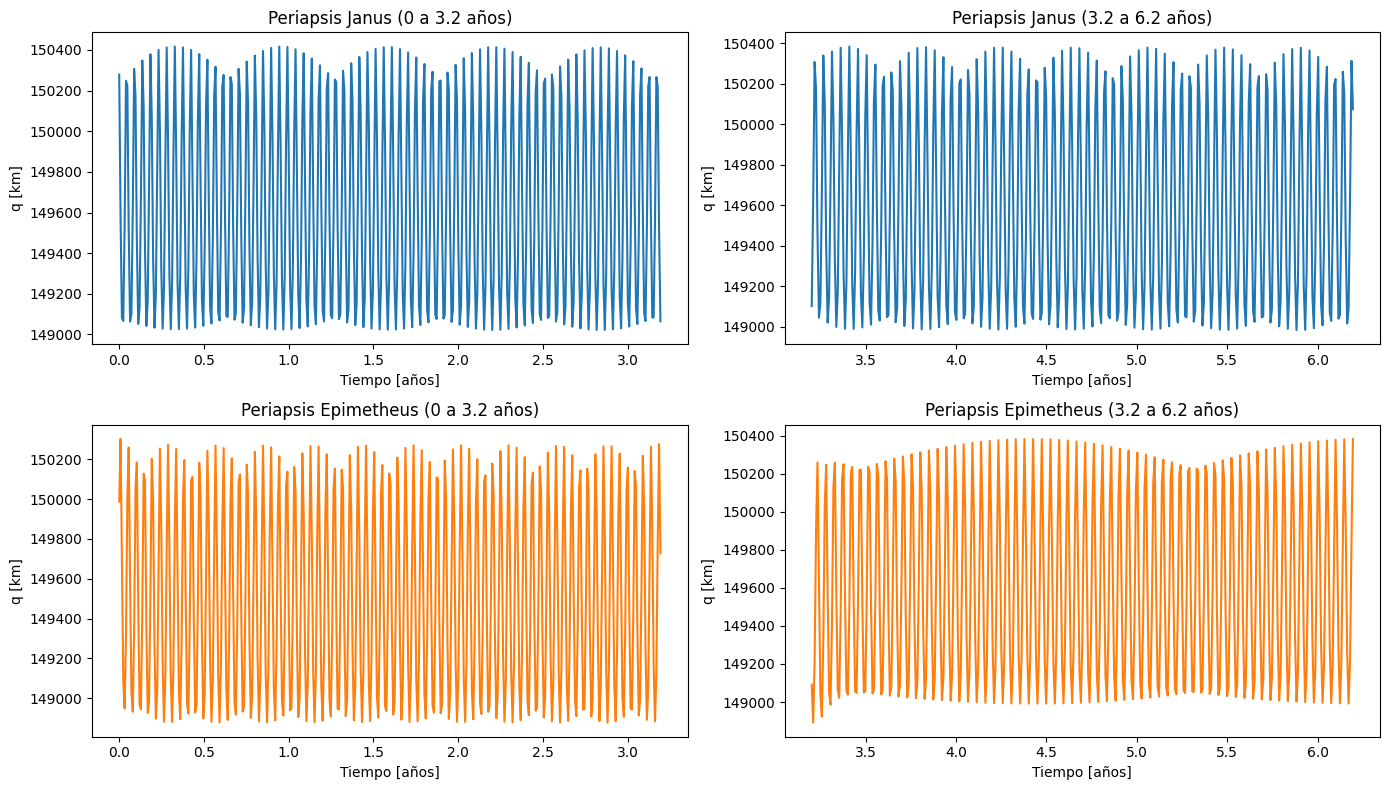

In [17]:
ts_years = ts / (four_years_in_canon / 4)

# Definimos máscaras booleanas para las ventanas de tiempo especificadas
window_1 = (ts_years >= 0) & (ts_years <= 3.2)
window_2 = (ts_years >= 3.2) & (ts_years <= 6.2)

# Convertimos a arreglos de numpy para poder indexar con las máscaras
q_j_np = np.array(q_s_j)
q_e_np = np.array(q_s_e)

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# --- Fila 1: Janus ---
axs[0, 0].plot(ts_years[window_1], q_j_np[window_1], color='C0')
axs[0, 0].set_title('Periapsis Janus (0 a 3.2 años)')
axs[0, 0].set_xlabel('Tiempo [años]')
axs[0, 0].set_ylabel('q [km]')

axs[0, 1].plot(ts_years[window_2], q_j_np[window_2], color='C0')
axs[0, 1].set_title('Periapsis Janus (3.2 a 6.2 años)')
axs[0, 1].set_xlabel('Tiempo [años]')
axs[0, 1].set_ylabel('q [km]')

# --- Fila 2: Epimetheus ---
axs[1, 0].plot(ts_years[window_1], q_e_np[window_1], color='C1')
axs[1, 0].set_title('Periapsis Epimetheus (0 a 3.2 años)')
axs[1, 0].set_xlabel('Tiempo [años]')
axs[1, 0].set_ylabel('q [km]')

axs[1, 1].plot(ts_years[window_2], q_e_np[window_2], color='C1')
axs[1, 1].set_title('Periapsis Epimetheus (3.2 a 6.2 años)')
axs[1, 1].set_xlabel('Tiempo [años]')
axs[1, 1].set_ylabel('q [km]')

plt.tight_layout()
plt.show()

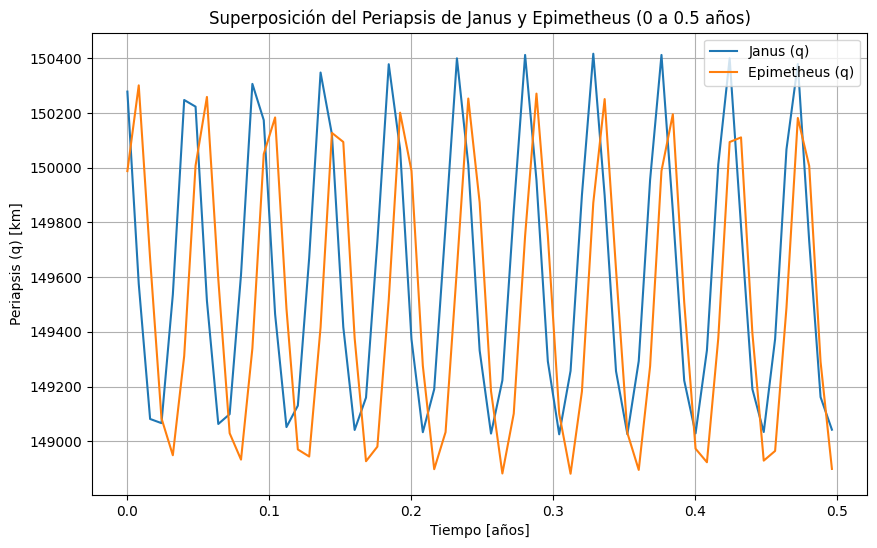

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(ts_years[window_1], q_j_np[window_1], label='Janus (q)', color='C0')
plt.plot(ts_years[window_1], q_e_np[window_1], label='Epimetheus (q)', color='C1')
plt.title('Superposición del Periapsis de Janus y Epimetheus (0 a 0.5 años)')
plt.xlabel('Tiempo [años]')
plt.ylabel('Periapsis (q) [km]')
plt.legend()
plt.grid(True)
plt.show()

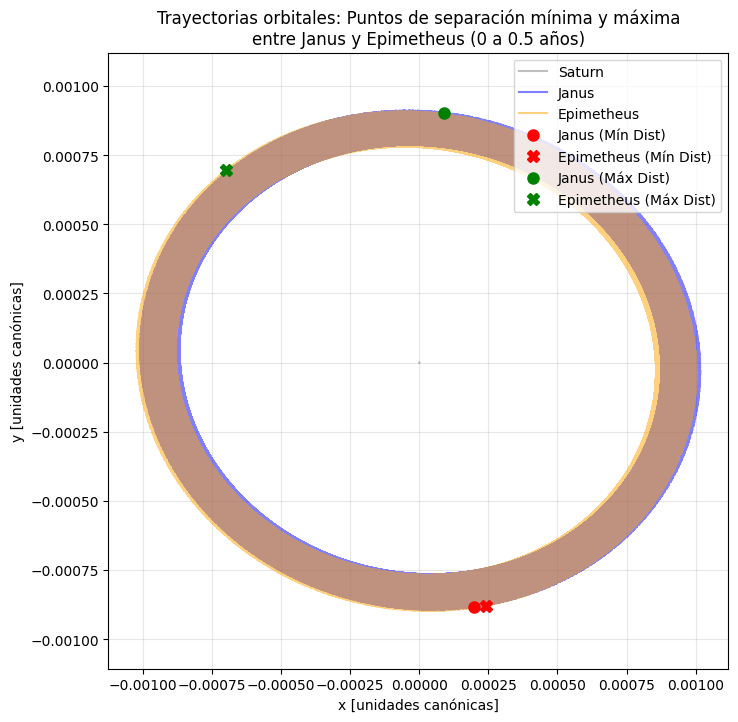

In [18]:
# Obtenemos los índices reales en todo el arreglo ts donde ocurren el mínimo y máximo
idx_window_1 = np.where(window_1)[0]
idx_min_dist = idx_window_1[np.argmin(distancia_je_window)]
idx_max_dist = idx_window_1[np.argmax(distancia_je_window)]

plt.figure(figsize=(8, 8))
# Trayectorias completas (basado en la celda 8)
plt.plot(rps[0,:,0], rps[0,:,1], label='Saturn', color='gray', alpha=0.5)
plt.plot(rps[1,:,0], rps[1,:,1], label='Janus', color='blue', alpha=0.5)
plt.plot(rps[2,:,0], rps[2,:,1], label='Epimetheus', color='orange', alpha=0.5)

# Trazar y resaltar las posiciones donde la distancia es mínima
plt.plot(rps[1, idx_min_dist, 0], rps[1, idx_min_dist, 1], 'ro', markersize=8, label='Janus (Mín Dist)')
plt.plot(rps[2, idx_min_dist, 0], rps[2, idx_min_dist, 1], 'rX', markersize=8, label='Epimetheus (Mín Dist)')

# Trazar y resaltar las posiciones donde la distancia es máxima
plt.plot(rps[1, idx_max_dist, 0], rps[1, idx_max_dist, 1], 'go', markersize=8, label='Janus (Máx Dist)')
plt.plot(rps[2, idx_max_dist, 0], rps[2, idx_max_dist, 1], 'gX', markersize=8, label='Epimetheus (Máx Dist)')

plt.xlabel('x [unidades canónicas]')
plt.ylabel('y [unidades canónicas]')
plt.title('Trayectorias orbitales: Puntos de separación mínima y máxima\nentre Janus y Epimetheus (0 a 0.5 años)')
plt.legend()
plt.axis('equal')
plt.grid(alpha=0.3)
plt.show()

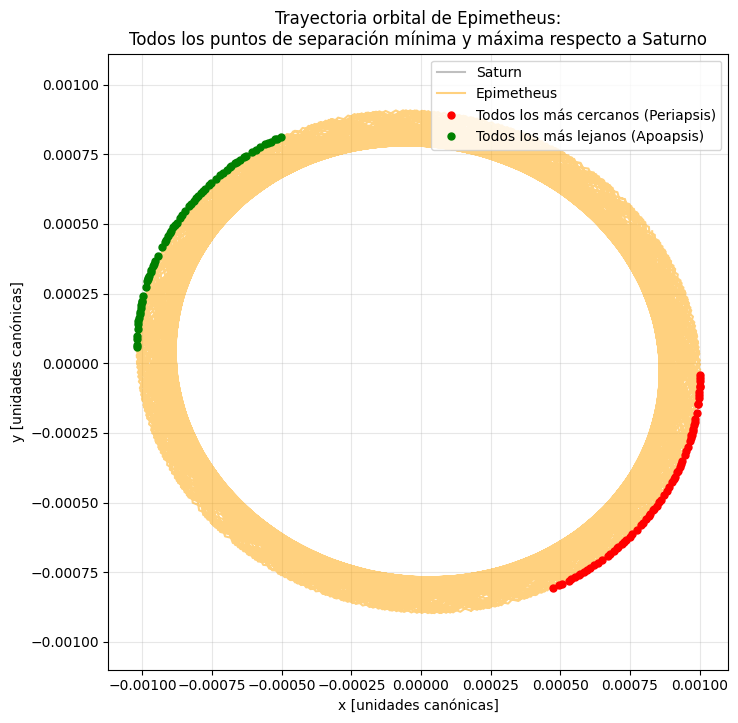

In [ ]:
from scipy.signal import find_peaks

plt.figure(figsize=(8, 8))

# Calcular distancia de Epimetheus a Saturno
dist_epim_sat = np.linalg.norm(rps[2, :, :] - rps[0, :, :], axis=1)

# Extraer solo la distancia en la ventana de tiempo
dist_window = dist_epim_sat[window_1]

# Encontrar TODOS los máximos locales (puntos más lejanos) y mínimos locales (puntos más cercanos)
peaks_max_rel, _ = find_peaks(dist_window)
peaks_min_rel, _ = find_peaks(-dist_window)

# Convertir los índices de la ventana a los índices reales de todo el arreglo 'ts'
idx_max_all = idx_window_1[peaks_max_rel]
idx_min_all = idx_window_1[peaks_min_rel]

# Trayectorias completas (sin Janus) para esta ventana de tiempo
plt.plot(rps[0, window_1, 0], rps[0, window_1, 1], label='Saturn', color='gray', alpha=0.5)
plt.plot(rps[2, window_1, 0], rps[2, window_1, 1], label='Epimetheus', color='orange', alpha=0.5)

# Trazar y resaltar TODOS los puntos de la distancia mínima y máxima de Epimetheus a Saturno
plt.plot(rps[2, idx_min_all, 0], rps[2, idx_min_all, 1], 'ro', markersize=5, linestyle='None', label='Todos los más cercanos (Periapsis)')
plt.plot(rps[2, idx_max_all, 0], rps[2, idx_max_all, 1], 'go', markersize=5, linestyle='None', label='Todos los más lejanos (Apoapsis)')

plt.xlabel('x [unidades canónicas]')
plt.ylabel('y [unidades canónicas]')
plt.title('Trayectoria orbital de Epimetheus:\nTodos los puntos de separación mínima y máxima respecto a Saturno')
plt.legend()
plt.axis('equal')
plt.grid(alpha=0.3)
plt.show()

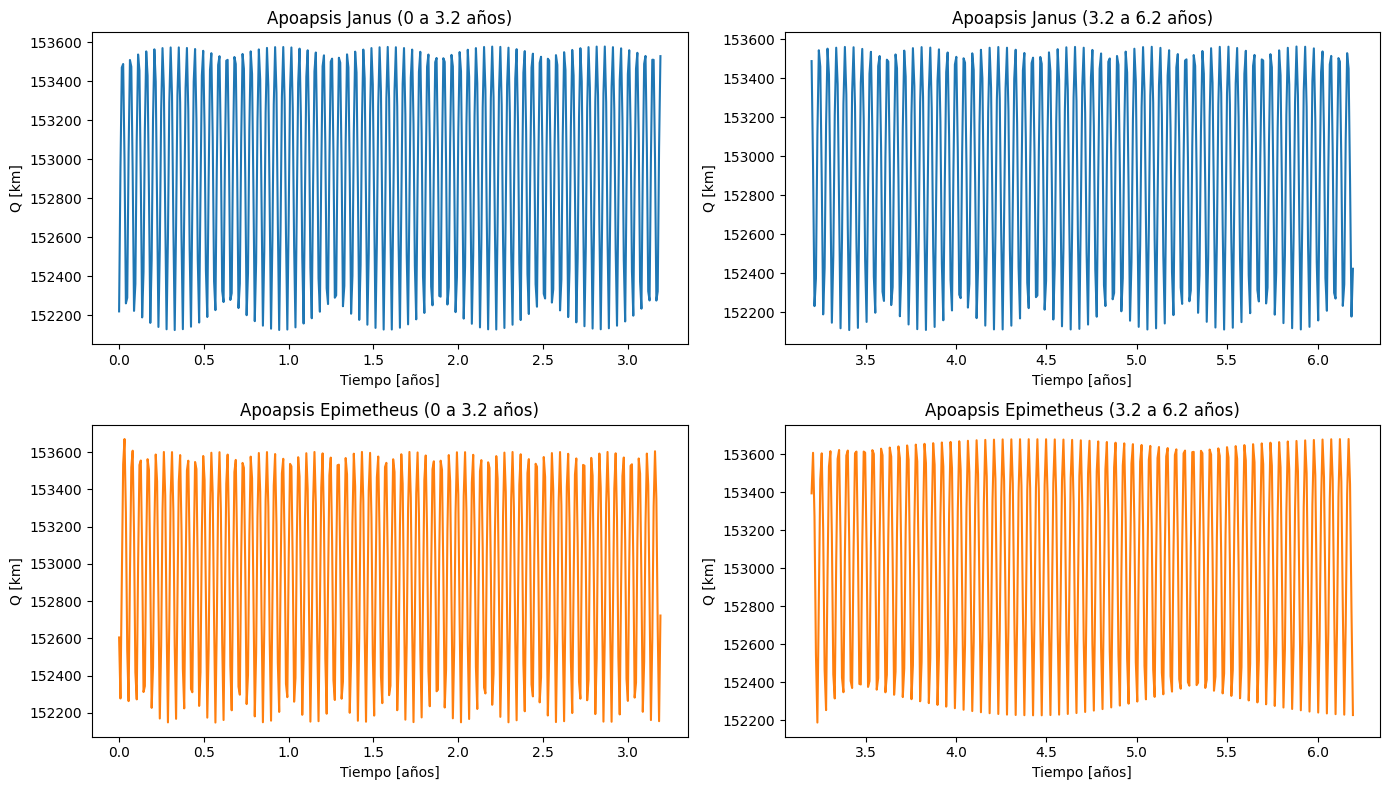

In [20]:
# --- Apoapsis Subplots ---
Q_j_np = np.array(Q_s_j)
Q_e_np = np.array(Q_s_e)

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Fila 1: Janus
axs[0, 0].plot(ts_years[window_1], Q_j_np[window_1], color='C0')
axs[0, 0].set_title('Apoapsis Janus (0 a 3.2 años)')
axs[0, 0].set_xlabel('Tiempo [años]')
axs[0, 0].set_ylabel('Q [km]')

axs[0, 1].plot(ts_years[window_2], Q_j_np[window_2], color='C0')
axs[0, 1].set_title('Apoapsis Janus (3.2 a 6.2 años)')
axs[0, 1].set_xlabel('Tiempo [años]')
axs[0, 1].set_ylabel('Q [km]')

# Fila 2: Epimetheus
axs[1, 0].plot(ts_years[window_1], Q_e_np[window_1], color='C1')
axs[1, 0].set_title('Apoapsis Epimetheus (0 a 3.2 años)')
axs[1, 0].set_xlabel('Tiempo [años]')
axs[1, 0].set_ylabel('Q [km]')

axs[1, 1].plot(ts_years[window_2], Q_e_np[window_2], color='C1')
axs[1, 1].set_title('Apoapsis Epimetheus (3.2 a 6.2 años)')
axs[1, 1].set_xlabel('Tiempo [años]')
axs[1, 1].set_ylabel('Q [km]')

plt.tight_layout()
plt.show()

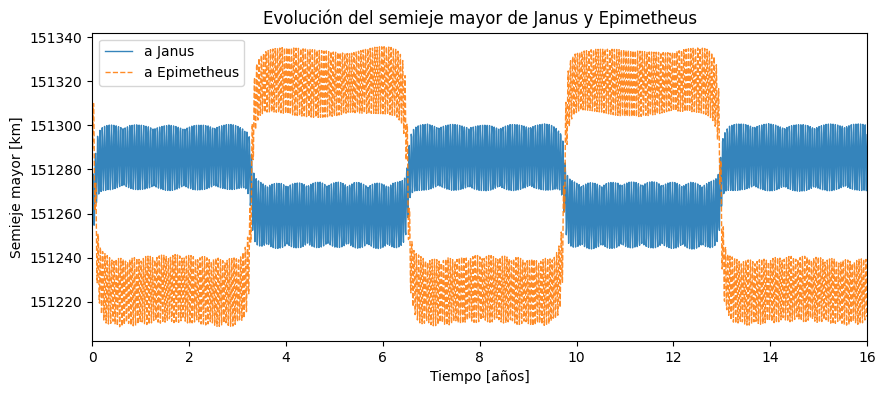

In [21]:
ts_years = ts / (four_years_in_canon / 4)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts_years, a_s_j, label='a Janus', linewidth=1, alpha=0.9)
ax.plot(ts_years, a_s_e, label='a Epimetheus', linestyle='--', linewidth=1, alpha=0.9)
ax.set_xlabel('Tiempo [años]')
ax.set_ylabel('Semieje mayor [km]')
ax.set_title('Evolución del semieje mayor de Janus y Epimetheus')
ax.set_xlim(0, 16)
ax.legend()
plt.show()

In [22]:
print("Semieje mayor maximo de Janus:", max(a_s_j))
print("Semieje mayor minimo de Janus:", min(a_s_j))
print("Semieje mayor maximo de Epimetheus:", max(a_s_e))
print("Semieje mayor minimo de Epimetheus:", min(a_s_e))

Semieje mayor maximo de Janus: 151300.78759686416
Semieje mayor minimo de Janus: 151243.85058064238
Semieje mayor maximo de Epimetheus: 151335.703081769
Semieje mayor minimo de Epimetheus: 151208.63034486436


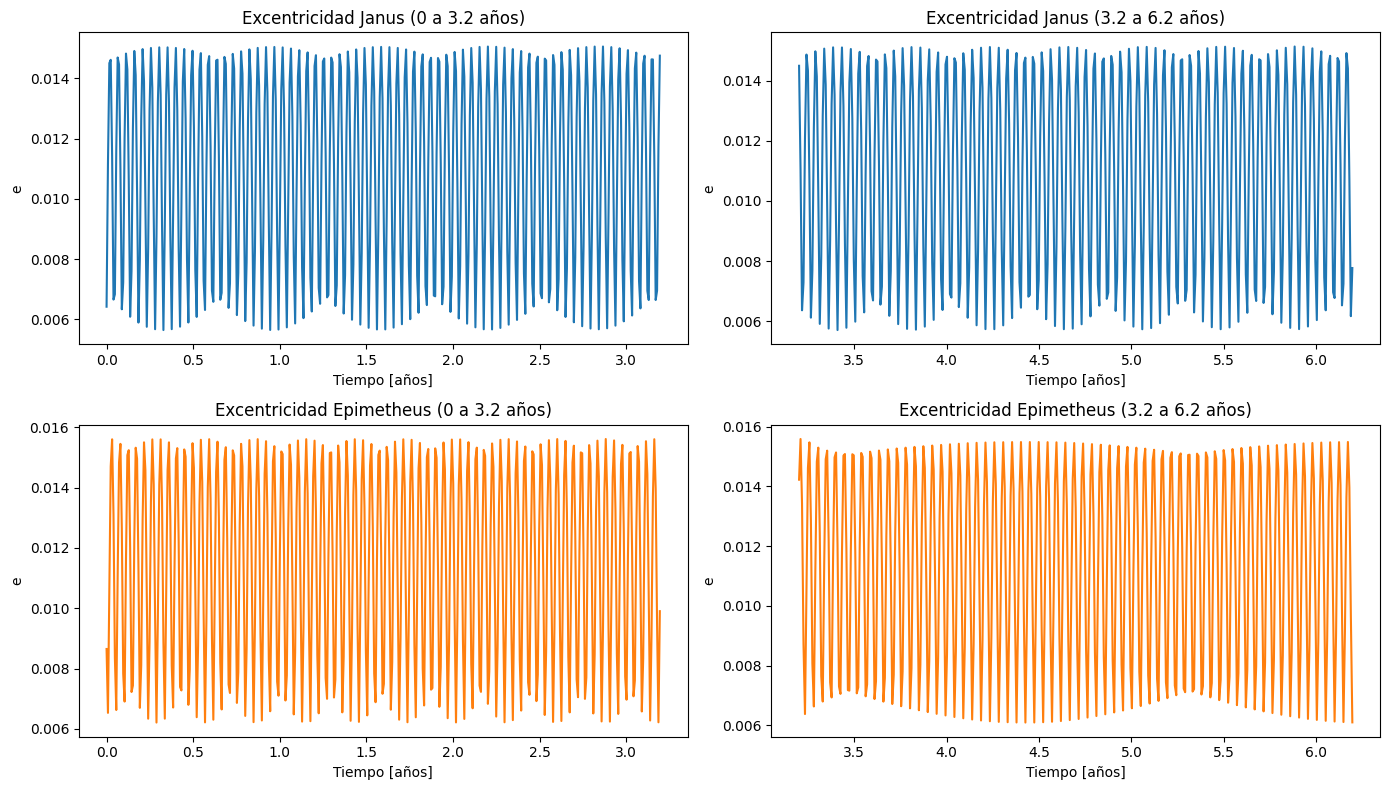

In [23]:
# --- Excentricidad Subplots ---
e_j_np = np.array(e_s_j)
e_e_np = np.array(e_s_e)

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Fila 1: Janus
axs[0, 0].plot(ts_years[window_1], e_j_np[window_1], color='C0')
axs[0, 0].set_title('Excentricidad Janus (0 a 3.2 años)')
axs[0, 0].set_xlabel('Tiempo [años]')
axs[0, 0].set_ylabel('e')

axs[0, 1].plot(ts_years[window_2], e_j_np[window_2], color='C0')
axs[0, 1].set_title('Excentricidad Janus (3.2 a 6.2 años)')
axs[0, 1].set_xlabel('Tiempo [años]')
axs[0, 1].set_ylabel('e')

# Fila 2: Epimetheus
axs[1, 0].plot(ts_years[window_1], e_e_np[window_1], color='C1')
axs[1, 0].set_title('Excentricidad Epimetheus (0 a 3.2 años)')
axs[1, 0].set_xlabel('Tiempo [años]')
axs[1, 0].set_ylabel('e')

axs[1, 1].plot(ts_years[window_2], e_e_np[window_2], color='C1')
axs[1, 1].set_title('Excentricidad Epimetheus (3.2 a 6.2 años)')
axs[1, 1].set_xlabel('Tiempo [años]')
axs[1, 1].set_ylabel('e')

plt.tight_layout()
plt.show()

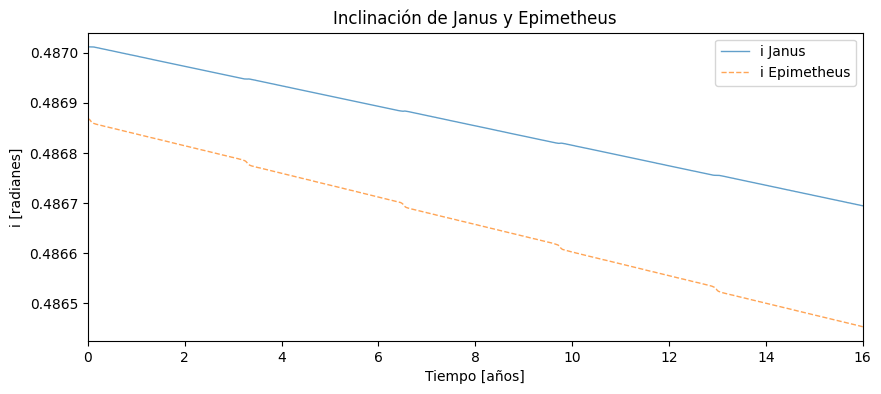

In [24]:
ts_years = ts / (four_years_in_canon / 4)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts_years, i_s_j, label='i Janus', linewidth=1, alpha=0.7)
ax.plot(ts_years, i_s_e, label='i Epimetheus', linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Tiempo [años]')
ax.set_ylabel('i [radianes]')
ax.set_title('Inclinación de Janus y Epimetheus')
ax.set_xlim(0, 16)
ax.legend()
plt.show()

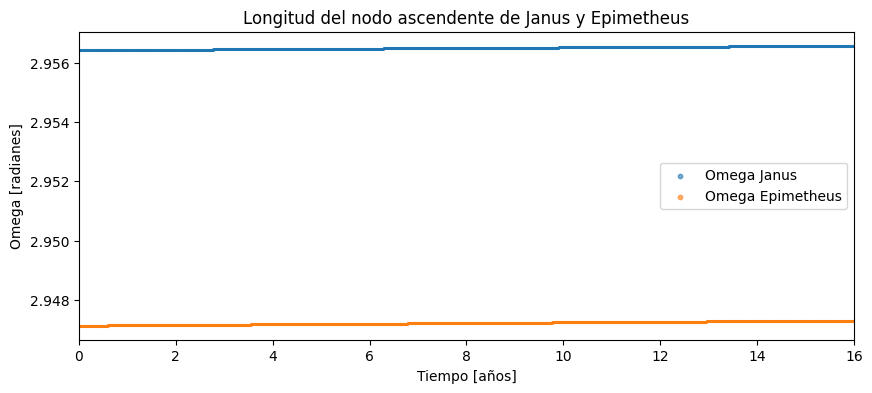

In [25]:
ts_years = ts / (four_years_in_canon / 4)

# Para variables angulares que cruzan los límites de 2*pi, 
# usar scatter previente que la línea de la gráfica salte de un lado al otro (zig-zag).
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(ts_years, Omega_s_j, label='Omega Janus', s=1.5, alpha=0.6)
ax.scatter(ts_years, Omega_s_e, label='Omega Epimetheus', s=1.5, alpha=0.6)
ax.set_xlabel('Tiempo [años]')
ax.set_ylabel('Omega [radianes]')
ax.set_title('Longitud del nodo ascendente de Janus y Epimetheus')
ax.set_xlim(0, 16)

# Mejorar el formato de la leyenda
leg = ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([10])

plt.show()

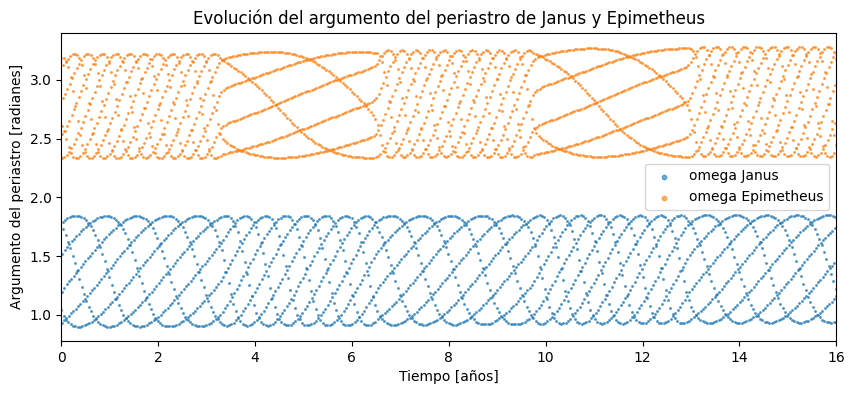

In [26]:
ts_years = ts / (four_years_in_canon / 4)

# Graficar ángulos con scatter evita grandes líneas verticales cruzando el eje.
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(ts_years, omega_s_j, label='omega Janus', s=1.5, alpha=0.6)
ax.scatter(ts_years, omega_s_e, label='omega Epimetheus', s=1.5, alpha=0.6)
ax.set_xlabel('Tiempo [años]')
ax.set_ylabel('Argumento del periastro [radianes]')
ax.set_title('Evolución del argumento del periastro de Janus y Epimetheus')
ax.set_xlim(0, 16)

leg = ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([10])

plt.show()

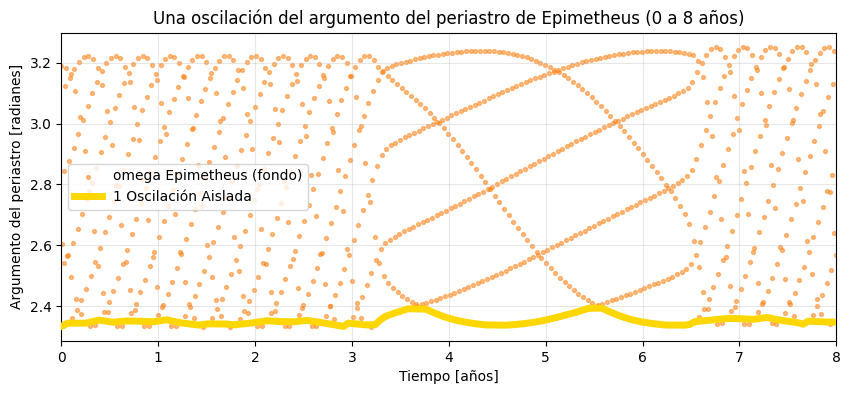

In [29]:
# Graficar una única oscilación del argumento del periastro de Epimetheus
omega_e_np = np.array(omega_s_e)
mask_osc = (ts_years >= 0) & (ts_years <= 8)
t_subset = ts_years[mask_osc]
omega_subset = omega_e_np[mask_osc]

# Para trazar la oscilación continua (debido al aliasing de la señal), rastreamos el camino saltando 
# al siguiente punto más cercano en omega
try:
    start_idx = np.where((t_subset > 2.1) & (omega_subset < 2.4))[0][0]
except IndexError:
    start_idx = 0 # Fallback 

strand_indices = [start_idx]
current_idx = start_idx

# Rastrear hacia adelante la rama
while True:
    search_window = 25
    next_indices = np.arange(current_idx + 1, min(current_idx + search_window, len(t_subset)))
    if len(next_indices) == 0:
        break
    
    diffs = np.abs(omega_subset[next_indices] - omega_subset[current_idx])
    best_next = next_indices[np.argmin(diffs)]
    
    if diffs[np.argmin(diffs)] > 0.05:  # Si el salto es mayor a la tolerancia, salimos
        break
    strand_indices.append(best_next)
    current_idx = best_next

# Rastrear hacia atrás para completar la oscilación desde el inicio
current_idx = start_idx
while True:
    search_window = 25
    prev_indices = np.arange(max(0, current_idx - search_window), current_idx)
    if len(prev_indices) == 0:
        break
    
    diffs = np.abs(omega_subset[prev_indices] - omega_subset[current_idx])
    best_prev = prev_indices[np.argmin(diffs)]
    
    if diffs[np.argmin(diffs)] > 0.05:
        break
        
    strand_indices.insert(0, best_prev)
    current_idx = best_prev

strand_indices = np.array(strand_indices)

fig, ax = plt.subplots(figsize=(10, 4))
# Graficar todo el fondo de aliasing
ax.scatter(t_subset, omega_subset, color='C1', label='omega Epimetheus (fondo)', s=8, alpha=0.5)

# Sobreponer y conectar la línea continua encontrada que forma una oscilación completa
if len(strand_indices) > 0:
    ax.plot(t_subset[strand_indices], omega_subset[strand_indices], color='gold', linewidth=5, label='1 Oscilación Aislada', zorder=5)

ax.set_xlabel('Tiempo [años]')
ax.set_ylabel('Argumento del periastro [radianes]')
ax.set_title('Una oscilación del argumento del periastro de Epimetheus (0 a 8 años)')
ax.set_xlim(0, 8)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

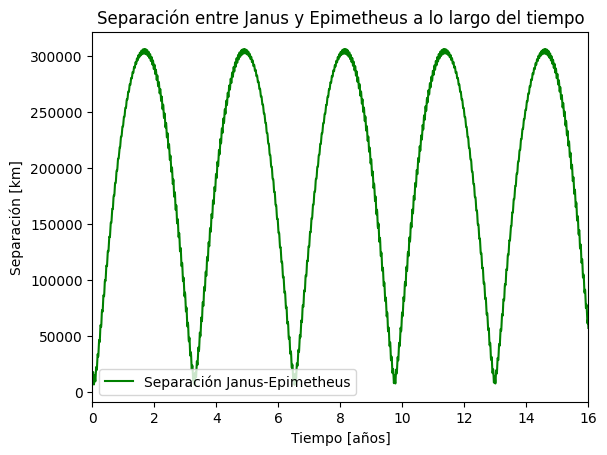

In [27]:
#separacion entre Janus y Epimetheus
AU_in_km = 149597870.7  # 1 AU in kilometers

# Index 1 is Janus, Index 2 is Epimetheus in the bodies list
rps_janus_epimetheus = np.sqrt(np.sum((rps[1,:,:] - rps[2,:,:])**2, axis=1)) * AU_in_km

# time in Earth years
ts_years = ts / (four_years_in_canon / 4)

plt.plot(ts_years, rps_janus_epimetheus, label='Separación Janus-Epimetheus', color='green')
plt.xlabel('Tiempo [años]')
plt.ylabel('Separación [km]')
plt.title('Separación entre Janus y Epimetheus a lo largo del tiempo')
plt.xlim(0, 16)
plt.legend()
plt.show()

In [ ]:
# Animación de la separación entre Janus y Epimetheus
fig, ax = plt.subplots(figsize=(10, 5))
camera = Camera(fig)

ax.set_xlabel('Tiempo [años]')
ax.set_ylabel('Separación [km]')
ax.set_title('Separación entre Janus y Epimetheus a lo largo del tiempo (Animación)')
ax.set_xlim(0, 16)
ax.set_ylim(min(rps_janus_epimetheus) * 0.95, max(rps_janus_epimetheus) * 1.05)
ax.grid(alpha=0.3)

# Submuestreo para que la animación no requiera demasiados cuadros
step_anim = max(1, len(ts_years) // 120)

for i in range(0, len(ts_years), step_anim):
    # Dibuja la línea verde hasta el tiempo actual
    ax.plot(ts_years[:i+1], rps_janus_epimetheus[:i+1], color='green')
    # Marca la posición actual con un punto rojo
    ax.plot(ts_years[i], rps_janus_epimetheus[i], 'ro', markersize=6)
    camera.snap()

anim = camera.animate(interval=60, blit=False)
plt.close(fig) # Cierra la figura estática para que solo se muestre la animación
display(HTML(anim.to_jshtml()))

In [28]:
print(f"Máxima separación entre Janus y Epimetheus: {max(rps_janus_epimetheus):.2f} km")
print(f"Mínima separación entre Janus y Epimetheus: {min(rps_janus_epimetheus):.2f} km")

Máxima separación entre Janus y Epimetheus: 306007.71 km
Mínima separación entre Janus y Epimetheus: 6159.12 km
